In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
DATA_PATH = Path("data/processed/videos_features.csv")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (205, 26)

Columns:
['ID', 'Category', 'Channel', 'Title', 'URL', 'Duration', 'Views', 'Explanation_Type', 'Visuals', 'Examples', 'Analogies', 'Real_Life', 'Quality', 'Creator_Takeaways', 'duration_seconds', 'views_numeric', 'combined_text', 'has_analogy', 'has_example', 'has_visual', 'has_math', 'has_code', 'has_application', 'log_views', 'text_length', 'word_count']


In [5]:
print(df["combined_text"].head(3).to_string())

0    Title: But what is a neural network? | Deep le...
1    Title: Gradient descent, how neural networks l...
2    Title: A Gentle Introduction to Machine Learni...


In [6]:
print("Missing combined_text:",
      df["combined_text"].isna().sum())

Missing combined_text: 0


In [10]:
%pip install sentence-transformers

  Using cached sentence_transformers-6.0.1-py3-none-any.whl.metadata (20 kB)
  Using cached transformers-5.17.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.31.0-py3-none-any.whl.metadata (16 kB)
  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
  Using cached tokenizers-0.23.2-cp310-abi3-win_amd64.whl.metadata (10 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
Using cached sentence_transformers-6.0.1-py3-none-any.whl (739 kB)
Using cached huggingface_hub-1.31.0-py3-none-any.whl (798 kB)
Using cached click-8.5.0-py3-none-any.whl (125 kB)
Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl (4.0 MB)
Using cached transformers-5.17.0-py3-none-any.whl (12.3 MB)
Using cached tokenizers-0.23.2-cp310-abi3-win_amd64.whl (2.9 MB)
Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl (355 kB

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.5.0 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\nagad\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [1]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully!")

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded successfully!


In [7]:
texts = df["combined_text"].tolist()

embeddings = embedding_model.encode(
    texts,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Embedding shape: (205, 384)


In [8]:
print("VID:", df["ID"].iloc[0])

print("\nFirst 20 embedding values:")
print(embeddings[0][:20])

VID: VID-001

First 20 embedding values:
[-7.4762829e-02 -1.4198685e-01  2.7558360e-02 -2.0045396e-02
 -5.6368876e-02  5.3387932e-02 -2.0674810e-02 -1.9430550e-02
 -2.9724684e-02 -6.0018022e-02 -7.1573667e-02  5.5757686e-03
  4.8190650e-05 -3.5807557e-02 -1.3024062e-01 -5.8289361e-03
  4.6999730e-02  5.1053204e-02 -5.1576454e-02 -2.0602610e-02]


In [9]:
EMBEDDING_PATH = Path(
    "data/processed/video_embeddings.npy"
)

np.save(EMBEDDING_PATH, embeddings)

print(f"Saved embeddings to: {EMBEDDING_PATH}")

Saved embeddings to: data\processed\video_embeddings.npy


In [10]:
loaded_embeddings = np.load(
    "data/processed/video_embeddings.npy"
)

print("Loaded shape:", loaded_embeddings.shape)

Loaded shape: (205, 384)


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

In [12]:
similarity_matrix = cosine_similarity(embeddings)

print("Similarity matrix shape:",
      similarity_matrix.shape)

Similarity matrix shape: (205, 205)


In [13]:
video_index = 0

similarities = similarity_matrix[video_index]

similar_indices = np.argsort(
    similarities
)[::-1]

In [14]:
results = df.iloc[similar_indices[:6]][
    ["ID", "Title", "Category"]
].copy()

results["similarity"] = similarities[similar_indices[:6]]

results

,ID,Title,Category,similarity
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),1.000000
20,VID-021,Neural Network Simply Explained | Deep Learnin...,Machine Learning (ML),0.763651
13,VID-014,Neural Networks Explained in 5 minutes,Machine Learning (ML),0.761549
22,VID-023,Convolutional Neural Networks (CNNs) explained,Machine Learning (ML),0.655551
23,VID-024,The Power of Recurrent Neural Networks (RNN),Machine Learning (ML),0.651878
21,VID-022,What are Convolutional Neural Networks (CNNs)?,Machine Learning (ML),0.641097


In [15]:
similar_indices = np.argsort(
    similarities
)[::-1]

similar_indices = [
    i for i in similar_indices
    if i != video_index
]

results = df.iloc[similar_indices[:5]][
    ["ID", "Title", "Category"]
].copy()

results["similarity"] = similarities[similar_indices[:5]]

results

,ID,Title,Category,similarity
20,VID-021,Neural Network Simply Explained | Deep Learnin...,Machine Learning (ML),0.763651
13,VID-014,Neural Networks Explained in 5 minutes,Machine Learning (ML),0.761549
22,VID-023,Convolutional Neural Networks (CNNs) explained,Machine Learning (ML),0.655551
23,VID-024,The Power of Recurrent Neural Networks (RNN),Machine Learning (ML),0.651878
21,VID-022,What are Convolutional Neural Networks (CNNs)?,Machine Learning (ML),0.641097


In [16]:
query = "Explain neural networks to a beginner"

query_embedding = embedding_model.encode(
    [query],
    convert_to_numpy=True
)

In [17]:
query_similarity = cosine_similarity(
    query_embedding,
    embeddings
)[0]

In [18]:
ranked_indices = np.argsort(
    query_similarity
)[::-1]

In [19]:
query_results = df.iloc[
    ranked_indices[:10]
][
    ["ID", "Title", "Category", "Channel"]
].copy()

query_results["similarity"] = query_similarity[
    ranked_indices[:10]
]

query_results

,ID,Title,Category,Channel,similarity
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,0.668459
20,VID-021,Neural Network Simply Explained | Deep Learnin...,Machine Learning (ML),codebasics,0.627737
13,VID-014,Neural Networks Explained in 5 minutes,Machine Learning (ML),IBM Technology,0.581852
23,VID-024,The Power of Recurrent Neural Networks (RNN),Machine Learning (ML),IBM Technology,0.558606
197,VID-198,Simply Explaining Deep Q-Learning/Deep Q-Netwo...,Reinforcement Learning & Game Theory,Johnny Code,0.545279
121,VID-122,Graph Neural Networks Explained: A Clear Guide...,Advanced Neural Architectures,IBM Technology,0.524983
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,0.518445
164,VID-165,Residual Networks (ResNet) [Physics Informed M...,Advanced Neural Architectures,Steve Brunton,0.516343
153,VID-154,Deep Q-Networks Explained!,Reinforcement Learning & Game Theory,CodeEmporium,0.511856
22,VID-023,Convolutional Neural Networks (CNNs) explained,Machine Learning (ML),deeplizard,0.496401


In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

embeddings_2d = pca.fit_transform(embeddings)

print(embeddings_2d.shape)

(205, 2)


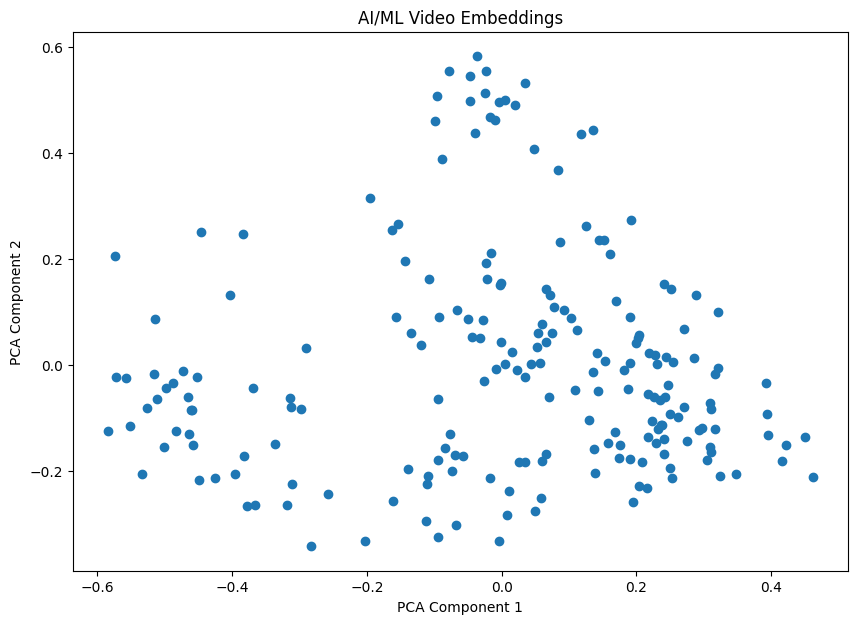

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1]
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("AI/ML Video Embeddings")

plt.show()

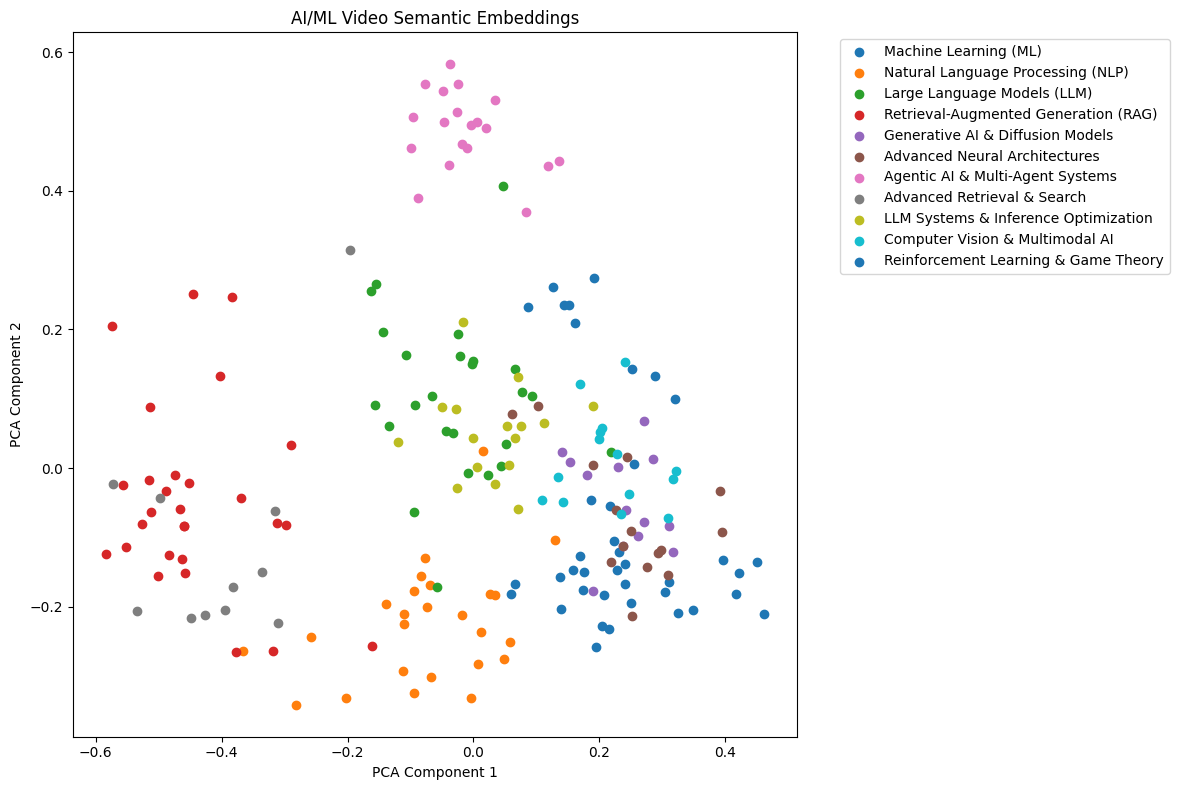

In [22]:
categories = df["Category"].unique()

plt.figure(figsize=(12, 8))

for category in categories:

    mask = df["Category"] == category

    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("AI/ML Video Semantic Embeddings")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [23]:
print("Number of videos:", len(df))
print("Embedding dimensions:", embeddings.shape[1])
print("Embedding matrix:", embeddings.shape)
print("Saved:", EMBEDDING_PATH)

Number of videos: 205
Embedding dimensions: 384
Embedding matrix: (205, 384)
Saved: data\processed\video_embeddings.npy
